# ** BERT Embeddings & Semantic Analysis**

## 
- Generate embeddings for resumes and job descriptions
- Analyze semantic similarity
- Prepare data for BERT fine-tuning
- Create training pairs with similarity labels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the cleaned ATS pairs dataset 
df = pd.read_csv('dataset/cleaned_resumeJD_pairs.csv')
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['match_label'].value_counts())
df.head(3)

Loaded: 301 rows, 5 columns
Columns: ['resume_text', 'job_description', 'match_score', 'match_label', 'match_label_lower']

Label distribution:
match_label
medium    101
high      100
low       100
Name: count, dtype: int64


,resume_text,job_description,match_score,match_label,match_label_lower
0,Python developer with 8 years of experience bu...,We need a Frontend Developer experienced with ...,0.44,medium,medium
1,UI/UX Designer with 3 years of experience in w...,Seeking a Business Analyst with experience in ...,0.41,medium,medium
2,Business Analyst with 9 years of experience in...,Seeking a Business Analyst with experience in ...,0.95,high,high


In [4]:
#01: loading the bert model
print("Loading BERT model...")
model = SentenceTransformer('all-mpnet-base-v2')

print("Model loaded!")
print(f"  Model:       all-mpnet-base-v2")
print(f"  Parameters:  22.7M")
print(f"  Embed dims:  768")
print(f"  Max tokens:  {model.max_seq_length}")

Loading BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!
  Model:       all-mpnet-base-v2
  Parameters:  22.7M
  Embed dims:  768
  Max tokens:  384


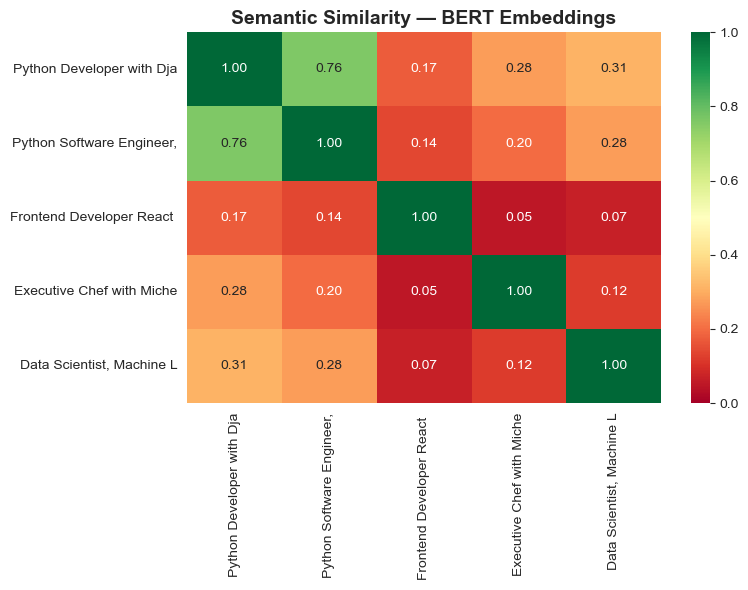

In [5]:
# Embeddings

texts = [
    "Python Developer with Django experience",
    "Python Software Engineer, Django REST APIs",
    "Frontend Developer React and JavaScript",
    "Executive Chef with Michelin experience",
    "Data Scientist, Machine Learning, PyTorch",
]

embeddings = model.encode(texts)
sim_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=[t[:25] for t in texts],
            yticklabels=[t[:25] for t in texts],
            vmin=0, vmax=1)
plt.title('Semantic Similarity — BERT Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
#generating resume and jd embeddings

print("Generating resume embeddings...")
resume_embeddings = model.encode(
    df['resume_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nGenerating job description embeddings...")
jd_embeddings = model.encode(
    df['job_description'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nResume embeddings shape:  {resume_embeddings.shape}")
print(f"JD embeddings shape:      {jd_embeddings.shape}")
print(f"Each text → {resume_embeddings.shape[1]}-dimensional vector")


Generating resume embeddings...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Generating job description embeddings...


Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Resume embeddings shape:  (301, 768)
JD embeddings shape:      (301, 768)
Each text → 768-dimensional vector


In [7]:
#Compute Cosine Similarity for Each Pair
#For each row: similarity between that resume and its paired JD

pair_similarities = []
for i in range(len(resume_embeddings)):
    sim = cosine_similarity([resume_embeddings[i]], [jd_embeddings[i]])[0][0]
    pair_similarities.append(sim)

df['bert_similarity'] = pair_similarities

print("Cosine similarity computed for all pairs.")
print(df[['match_label', 'match_score', 'bert_similarity']].head(10))


Cosine similarity computed for all pairs.
  match_label  match_score  bert_similarity
0      medium         0.44         0.733763
1      medium         0.41         0.508780
2        high         0.95         0.826857
3      medium         0.66         0.630581
4         low         0.34         0.619085
5      medium         0.44         0.601879
6        high         0.78         0.844900
7         low         0.34         0.556652
8      medium         0.61         0.572013
9         low         0.30         0.394444


In [8]:
#Base Model Performance

mae  = mean_absolute_error(df['match_score'], df['bert_similarity'])
rmse = np.sqrt(mean_squared_error(df['match_score'], df['bert_similarity']))

print("Base BERT Model Performance (before fine-tuning)")
print("=" * 50)
print(f"  MAE:  {mae:.4f}   (lower is better)")
print(f"  RMSE: {rmse:.4f}   (lower is better)")
print()

Base BERT Model Performance (before fine-tuning)
  MAE:  0.1649   (lower is better)
  RMSE: 0.2190   (lower is better)



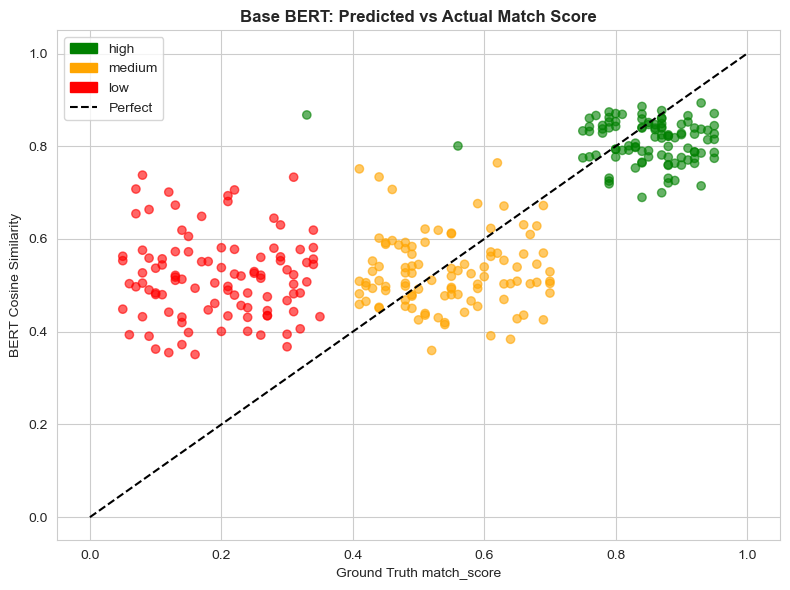

In [9]:
# Scatter
plt.figure(figsize=(8, 6))
colors = df['match_label'].map({'low': 'red', 'medium': 'orange', 'high': 'green'})
plt.scatter(df['match_score'], df['bert_similarity'], c=colors, alpha=0.6)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect prediction')
plt.xlabel('Ground Truth match_score')
plt.ylabel('BERT Cosine Similarity')
plt.title('Base BERT: Predicted vs Actual Match Score', fontweight='bold')

# Legend
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='green', label='high'),
    Patch(color='orange', label='medium'),
    Patch(color='red', label='low'),
    plt.Line2D([0],[0], color='black', linestyle='--', label='Perfect')
])
plt.tight_layout()
plt.show()

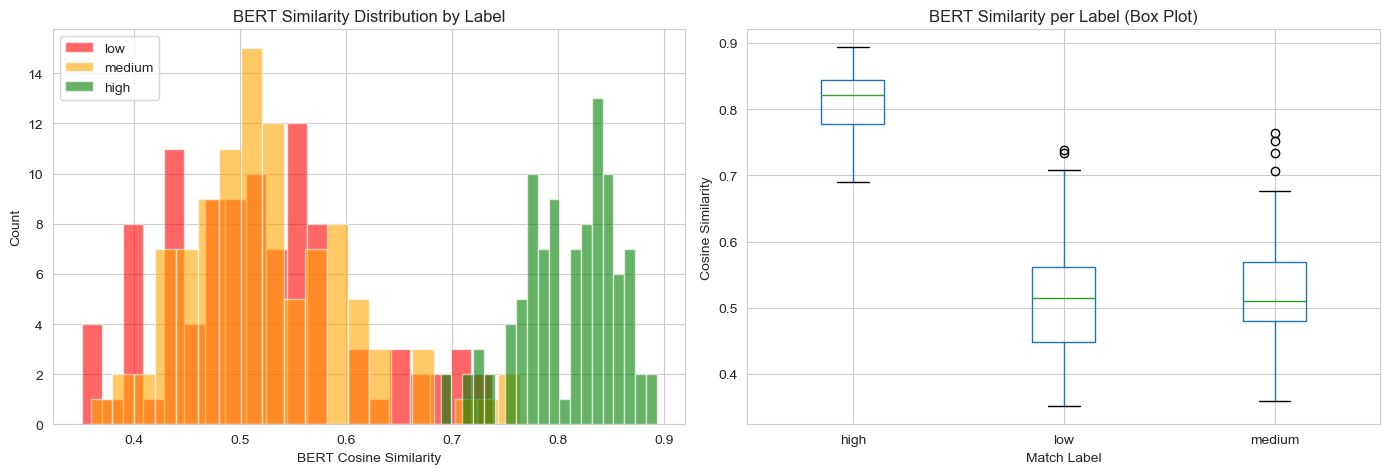


Overlap between labels = base model struggles to separate high vs low matches


In [11]:
#Similarity Distribution by Label

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: BERT similarity grouped by label
for label, color in [('low','red'), ('medium','orange'), ('high','green')]:
    subset = df[df['match_label'] == label]['bert_similarity']
    axes[0].hist(subset, bins=20, alpha=0.6, label=label, color=color)
axes[0].set_xlabel('BERT Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('BERT Similarity Distribution by Label')
axes[0].legend()

# Box plot
df.boxplot(column='bert_similarity', by='match_label',
           positions=[0,1,2], ax=axes[1])
axes[1].set_title('BERT Similarity per Label (Box Plot)')
axes[1].set_xlabel('Match Label')
axes[1].set_ylabel('Cosine Similarity')
plt.suptitle('')

plt.tight_layout()
plt.show()


print("\nOverlap between labels = base model struggles to separate high vs low matches")


In [13]:
#Per-Label Error Analysis

df['error'] = abs(df['match_score'] - df['bert_similarity'])

print("Average error per label:")
print(df.groupby('match_label')['error'].mean().round(4))
print()

# Show the worst predictions
print("Top 5 worst predictions:")
df.nlargest(5, 'error')[['match_label','match_score','bert_similarity','error']]

Average error per label:
match_label
high      0.0787
low       0.3213
medium    0.0955
Name: error, dtype: float64

Top 5 worst predictions:


,match_label,match_score,bert_similarity,error
194,low,0.08,0.737751,0.657751
127,low,0.07,0.707684,0.637684
192,low,0.07,0.654504,0.584504
237,low,0.12,0.701120,0.581120
260,low,0.09,0.663509,0.573509


In [15]:
import pickle

with open('resume_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'resume_embeddings': resume_embeddings,
        'jd_embeddings':     jd_embeddings,
        'match_scores':      df['match_score'].tolist(),
        'match_labels':      df['match_label'].tolist(),
    }, f)

print("Saved: resume_embeddings.pkl")
print(f"  resume_embeddings: {resume_embeddings.shape}")
print(f"  jd_embeddings:     {jd_embeddings.shape}")
print()
print("These will be loaded for fine-tuning.")

Saved: resume_embeddings.pkl
  resume_embeddings: (301, 768)
  jd_embeddings:     (301, 768)

These will be loaded for fine-tuning.
